In [1]:
import pandas as pd

In [2]:
path= "/content/drive/MyDrive/cattle data/cattle data"

In [3]:
import os

image_extensions = ('.jpg', '.jpeg', '.png', '.gif')

if os.path.exists(path):
    print(f"Searching in: {path}")
    for root, dirs, files in os.walk(path):
        if root == path: # Only consider direct subfolders, not the root itself
            for folder_name in dirs:
                folder_path = os.path.join(root, folder_name)
                image_count = 0
                for _, _, sub_files in os.walk(folder_path):
                    for file in sub_files:
                        if file.lower().endswith(image_extensions):
                            image_count += 1
                print(f"Folder: '{folder_name}' - Images: {image_count}")
            break # Stop after processing direct subfolders
else:
    print(f"The path '{path}' does not exist or is not accessible.")

Searching in: /content/drive/MyDrive/cattle data/cattle data
Folder: 'HEALTHY LSD' - Images: 734
Folder: 'HEALTHY FMD' - Images: 472
Folder: 'FMD' - Images: 268
Folder: 'LSD' - Images: 483


Displaying up to 4 images for each class from: /content/drive/MyDrive/cattle data/cattle data

Class: HEALTHY LSD


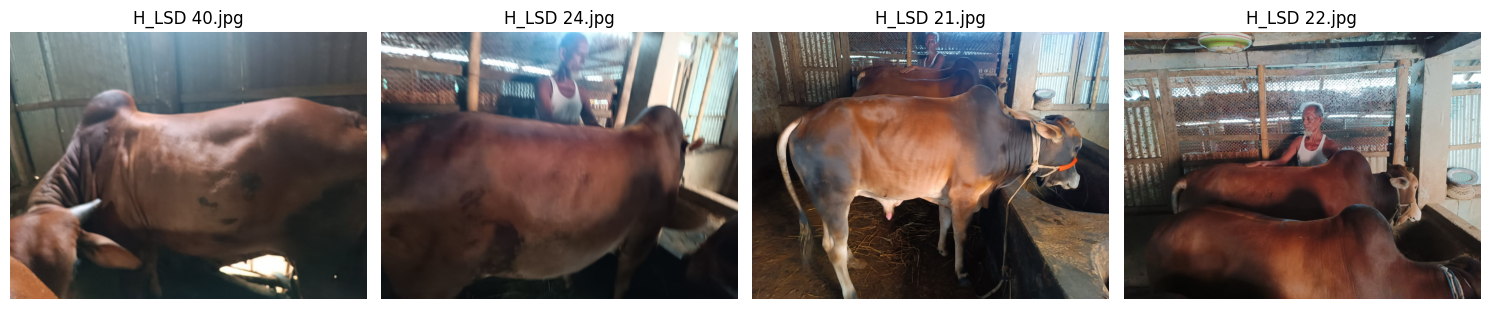


Class: HEALTHY FMD


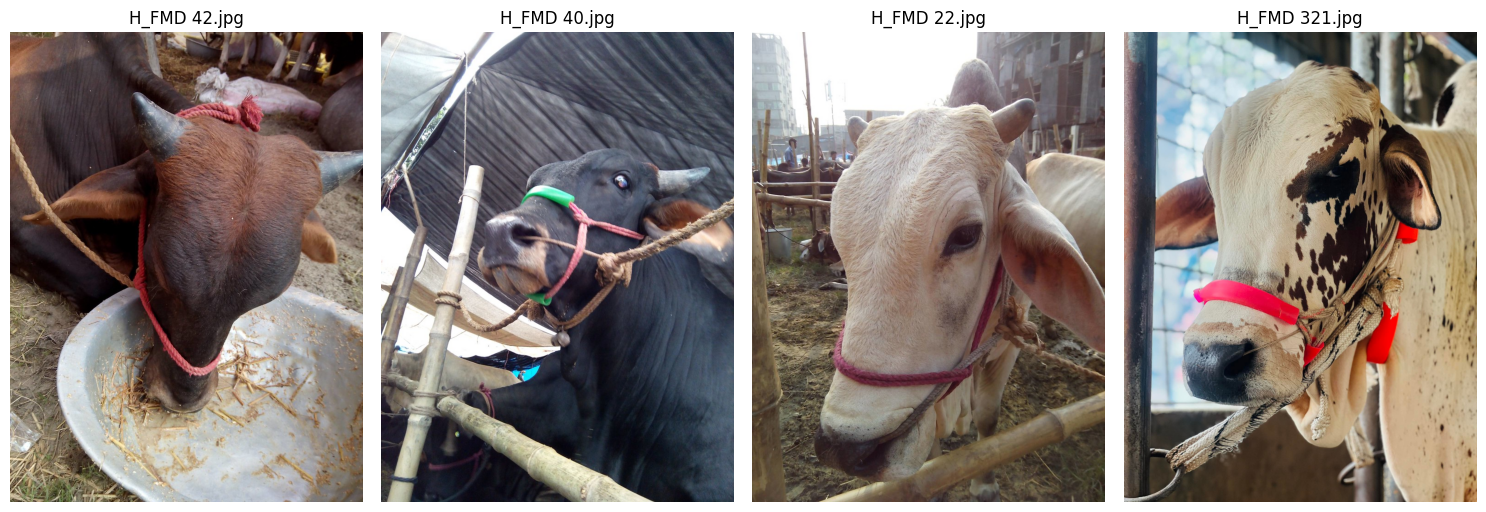


Class: FMD


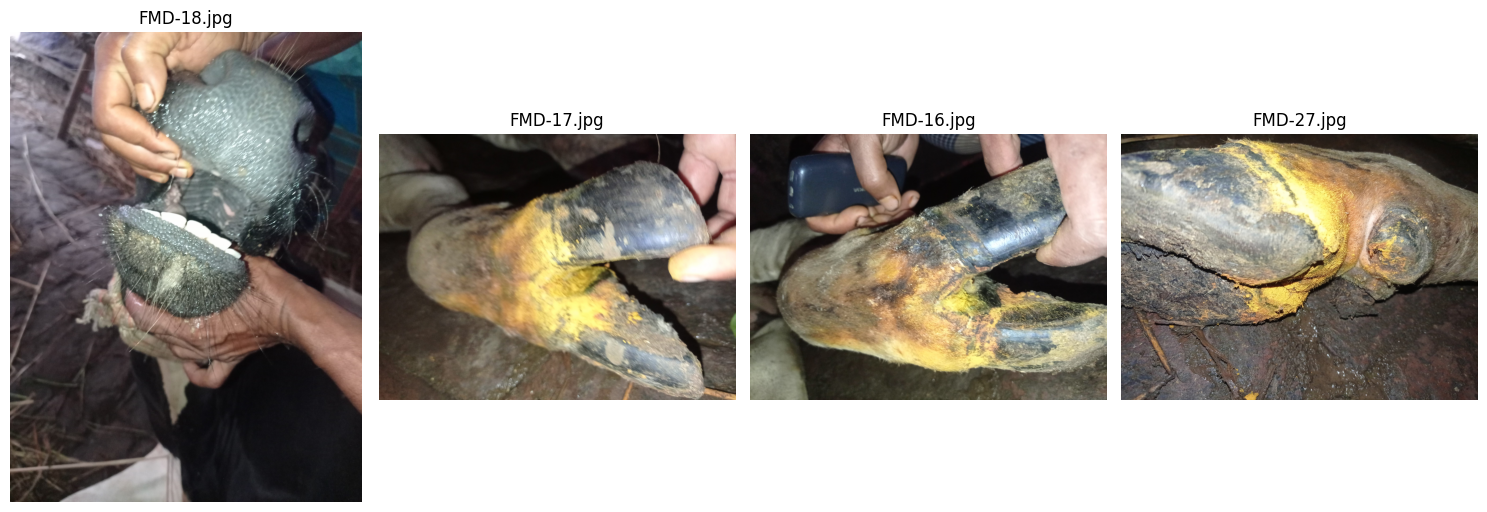


Class: LSD


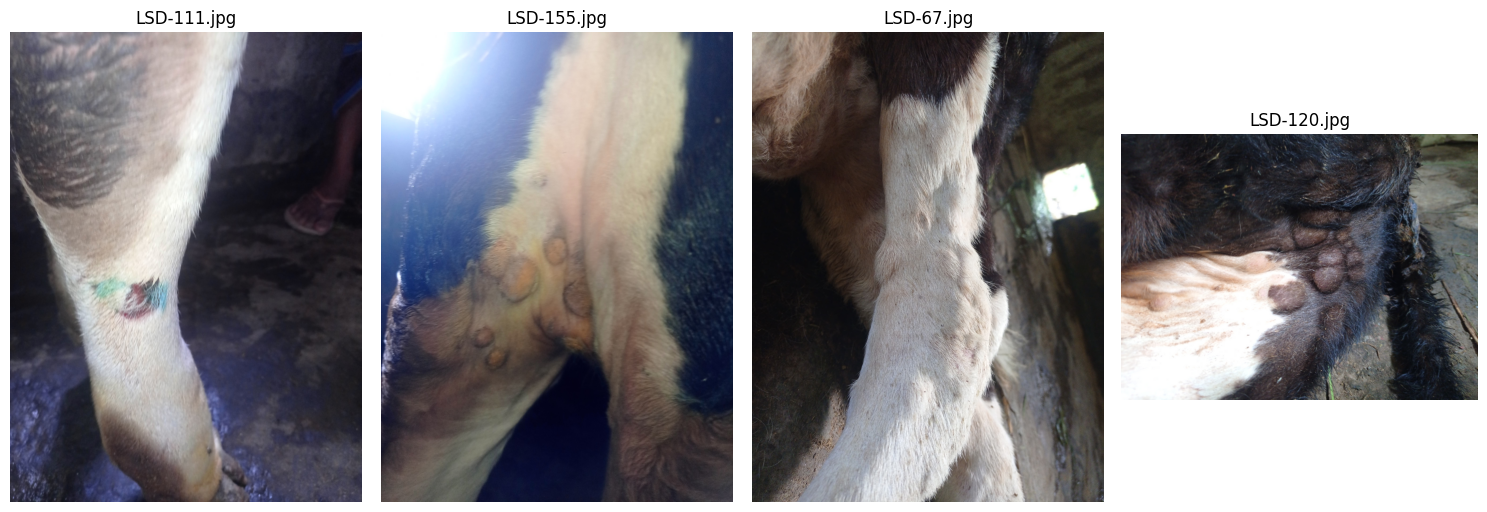

In [4]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image
import os

image_extensions = ('.jpg', '.jpeg', '.png', '.gif')

# Assuming 'path' variable is already defined from previous cells
# e.g., path = '/content/drive/MyDrive/cattle data/cattle data'

if 'path' not in locals():
    print("Error: 'path' variable is not defined. Please define the base path first.")
else:
    print(f"Displaying up to 4 images for each class from: {path}")

    # Get direct subfolders (classes)
    class_folders = [f.name for f in os.scandir(path) if f.is_dir()]

    for folder_name in class_folders:
        folder_path = os.path.join(path, folder_name)
        print(f"\nClass: {folder_name}")

        image_files = []
        for file in os.listdir(folder_path):
            if file.lower().endswith(image_extensions):
                image_files.append(os.path.join(folder_path, file))

        if not image_files:
            print("  No images found in this folder.")
            continue

        # Display up to 4 images
        num_images_to_display = min(4, len(image_files))
        if num_images_to_display > 0:
            fig, axes = plt.subplots(1, num_images_to_display, figsize=(15, 5))
            if num_images_to_display == 1:
                axes = [axes] # Make it iterable for a single image

            for i in range(num_images_to_display):
                img_path = image_files[i]
                try:
                    img = Image.open(img_path)
                    axes[i].imshow(img)
                    axes[i].set_title(os.path.basename(img_path))
                    axes[i].axis('off')
                except Exception as e:
                    print(f"  Could not load image {img_path}: {e}")
            plt.tight_layout()
            plt.show()
        else:
            print("  No images to display.")

In [5]:
import os
from PIL import Image

image_extensions = ('.jpg', '.jpeg', '.png', '.gif')

if 'path' not in locals():
    print("Error: 'path' variable is not defined. Please define the base path first.")
else:
    print(f"Analyzing image resolutions in: {path}\n")

    # Get direct subfolders (classes)
    class_folders = [f.name for f in os.scandir(path) if f.is_dir()]

    for folder_name in class_folders:
        folder_path = os.path.join(path, folder_name)
        print(f"Folder: {folder_name}")

        resolution_counts = {}
        image_files_in_folder = []
        for file in os.listdir(folder_path):
            if file.lower().endswith(image_extensions):
                image_files_in_folder.append(os.path.join(folder_path, file))

        if not image_files_in_folder:
            print("  No images found in this folder.")
            print("-------------------------------------")
            continue

        for img_path in image_files_in_folder:
            try:
                with Image.open(img_path) as img:
                    resolution = img.size # (width, height)
                    resolution_counts[resolution] = resolution_counts.get(resolution, 0) + 1
            except Exception as e:
                print(f"  Could not read image {os.path.basename(img_path)} for resolution check: {e}")

        if resolution_counts:
            for res, count in resolution_counts.items():
                print(f"  Resolution {res[0]}x{res[1]}: {count} images")
        else:
            print("  No valid image resolutions found.")
        print("-------------------------------------")

Analyzing image resolutions in: /content/drive/MyDrive/cattle data/cattle data

Folder: HEALTHY LSD
  Resolution 1600x1200: 27 images
  Resolution 500x500: 7 images
  Resolution 500x375: 1 images
  Resolution 1456x1006: 1 images
  Resolution 500x282: 1 images
  Resolution 300x300: 6 images
  Resolution 200x200: 1 images
  Resolution 600x600: 12 images
  Resolution 750x450: 1 images
  Resolution 2250x1650: 1 images
  Resolution 150x150: 1 images
  Resolution 1024x768: 4 images
  Resolution 1284x870: 1 images
  Resolution 2048x1152: 78 images
  Resolution 1080x810: 9 images
  Resolution 2016x1512: 12 images
  Resolution 1080x608: 5 images
  Resolution 2048x1365: 18 images
  Resolution 2048x1536: 159 images
  Resolution 1284x672: 1 images
  Resolution 1284x924: 1 images
  Resolution 1284x1332: 1 images
  Resolution 2048x1542: 2 images
  Resolution 828x1126: 1 images
  Resolution 1286x1120: 1 images
  Resolution 2312x1068: 1 images
  Resolution 1284x720: 3 images
  Resolution 1080x840: 1 i

In [6]:
# Install necessary libraries if not already installed
!pip install pillow openpyxl --quiet

import os
from pathlib import Path
from datetime import datetime

from PIL import Image
from PIL.ExifTags import TAGS
import openpyxl
from openpyxl.styles import Font, PatternFill, Alignment
from openpyxl.utils import get_column_letter

# ---------------------------------------------------------------------------
# CONFIG -- adapted for Colab
# ---------------------------------------------------------------------------
# Use the 'path' variable already defined in the notebook
if 'path' not in locals():
    print("Error: 'path' variable is not defined. Please define the base path first.")
    # Fallback or exit if path is not defined
    ROOT_DIR = "./dataset_placeholder" # This will likely cause an error if path is not set
else:
    ROOT_DIR = path  # Use the existing path variable

# Output Excel file will be saved in the content directory
OUTPUT_XLSX = "/content/dataset_provenance_report.xlsx"

# Software tags commonly left by web tools / re-saves / screenshots
# rather than a camera or phone's native camera app.
SUSPICIOUS_SOFTWARE_KEYWORDS = [
    "photoshop", "gimp", "paint", "facebook", "whatsapp", "instagram",
    "screenshot", "snipping", "canva", "picasa", "irfanview",
    "google", "windows photo", "preview", "acdsee",
]

SMALL_DIM_THRESHOLD = 600  # px; below this on the short side is suspicious


def get_exif_dict(img):
    """Returns a dict of readable EXIF tags, or {} if none present."""
    try:
        raw = img._getexif()
    except Exception:
        raw = None
    if not raw:
        return {}
    out = {}
    for tag_id, value in raw.items():
        tag = TAGS.get(tag_id, tag_id)
        out[tag] = value
    return out


def classify_provenance(width, height, exif, file_size_kb):
    """
    Heuristic classification. Returns (verdict, reasons_list).
    verdict is one of: 'likely_field_photo', 'likely_web_scraped', 'uncertain'
    """
    reasons = []
    score = 0  # positive = looks like a real field photo, negative = looks scraped

    has_make = bool(exif.get("Make"))
    has_model = bool(exif.get("Model"))
    has_datetime = bool(exif.get("DateTimeOriginal") or exif.get("DateTime"))
    software = str(exif.get("Software", "")).lower()

    if has_make and has_model:
        score += 2
        reasons.append(f"has camera Make/Model ({exif.get('Make')} {exif.get('Model')})")
    else:
        score -= 1
        reasons.append("no camera Make/Model in EXIF")

    if has_datetime:
        score += 1
        reasons.append("has capture DateTime")
    else:
        score -= 1
        reasons.append("no capture DateTime in EXIF")

    if software:
        if any(kw in software for kw in SUSPICIOUS_SOFTWARE_KEYWORDS):
            score -= 2
            reasons.append(f"Software tag suggests re-save/edit tool: '{exif.get('Software')}'")
        else:
            reasons.append(f"Software tag present: '{exif.get('Software')}'")

    if width is not None and height is not None and min(width, height) < SMALL_DIM_THRESHOLD:
        score -= 1
        reasons.append(f"small resolution ({width}x{height})")

    if file_size_kb is not None and file_size_kb < 30:
        score -= 1
        reasons.append(f"very small file size ({file_size_kb:.0f} KB, suggests re-compression)")

    if not exif:
        score -= 1
        reasons.append("no EXIF block at all (common after web download/re-save)")

    if score >= 2:
        verdict = "likely_field_photo"
    elif score <= -2:
        verdict = "likely_web_scraped"
    else:
        verdict = "uncertain"

    return verdict, reasons


def scan_folder(root_dir):
    root = Path(root_dir)
    rows = []
    valid_ext = (".jpg", ".jpeg", ".png", ".bmp", ".tiff", ".webp")

    if not root.exists():
        print(f"The specified ROOT_DIR '{root_dir}' does not exist. Skipping scan.")
        return []

    for class_folder in sorted([d for d in root.iterdir() if d.is_dir()]):
        class_name = class_folder.name
        for img_path in sorted(class_folder.rglob("*")):
            if img_path.suffix.lower() not in valid_ext:
                continue

            try:
                file_size_kb = img_path.stat().st_size / 1024
                with Image.open(img_path) as img:
                    width, height = img.size
                    exif = get_exif_dict(img)
            except Exception as e:
                rows.append({
                    "class": class_name,
                    "filename": img_path.name,
                    "filepath": str(img_path),
                    "width": None, "height": None,
                    "camera_make": None, "camera_model": None,
                    "datetime_original": None, "software": None,
                    "file_size_kb": None,
                    "verdict": "ERROR_COULD_NOT_READ",
                    "reasons": str(e),
                })
                continue

            verdict, reasons = classify_provenance(width, height, exif, file_size_kb)

            rows.append({
                "class": class_name,
                "filename": img_path.name,
                "filepath": str(img_path),
                "width": width,
                "height": height,
                "camera_make": exif.get("Make"),
                "camera_model": exif.get("Model"),
                "datetime_original": str(exif.get("DateTimeOriginal") or exif.get("DateTime") or ""),
                "software": exif.get("Software"),
                "file_size_kb": round(file_size_kb, 1),
                "verdict": verdict,
                "reasons": "; ".join(reasons),
            })

    return rows


def write_excel(rows, output_path):
    wb = openpyxl.Workbook()
    ws = wb.active
    ws.title = "Image Provenance"

    headers = ["Class", "Filename", "Filepath", "Width", "Height",
               "Camera Make", "Camera Model", "Capture DateTime",
               "Software Tag", "File Size (KB)", "Verdict", "Reasons"]
    ws.append(headers)

    header_font = Font(name="Arial", bold=True, color="FFFFFF")
    header_fill = PatternFill(start_color="2F5597", end_color="2F5597", fill_type="solid")
    for col_idx, _ in enumerate(headers, start=1):
        cell = ws.cell(row=1, column=col_idx)
        cell.font = header_font
        cell.fill = header_fill
        cell.alignment = Alignment(horizontal="center")

    verdict_fill = {
        "likely_field_photo": PatternFill(start_color="C6EFCE", end_color="C6EFCE", fill_type="solid"),
        "likely_web_scraped": PatternFill(start_color="FFC7CE", end_color="FFC7CE", fill_type="solid"),
        "uncertain": PatternFill(start_color="FFEB9C", end_color="FFEB9C", fill_type="solid"),
        "ERROR_COULD_NOT_READ": PatternFill(start_color="D9D9D9", end_color="D9D9D9", fill_type="solid"),
    }

    for row in rows:
        ws.append([
            row["class"], row["filename"], row["filepath"],
            row["width"], row["height"],
            row["camera_make"], row["camera_model"],
            row["datetime_original"], row["software"],
            row["file_size_kb"], row["verdict"], row["reasons"],
        ])
        r = ws.max_row
        fill = verdict_fill.get(row["verdict"])
        if fill:
            ws.cell(row=r, column=11).fill = fill
        for c in range(1, len(headers) + 1):
            ws.cell(row=r, column=c).font = Font(name="Arial", size=10)

    # column widths
    widths = [14, 30, 45, 8, 8, 16, 20, 20, 22, 14, 20, 60]
    for i, w in enumerate(widths, start=1):
        ws.column_dimensions[get_column_letter(i)].width = w

    ws.freeze_panes = "A2"
    ws.auto_filter.ref = f"A1:{get_column_letter(len(headers))}{ws.max_row}"

    # summary sheet
    ws2 = wb.create_sheet("Summary")
    ws2.append(["Class", "Total", "Likely Field Photo", "Likely Web-Scraped", "Uncertain", "Error"])
    for c in ws2[1]:
        c.font = header_font
        c.fill = header_fill

    classes = sorted(set(r["class"] for r in rows))
    for cls in classes:
        cls_rows = [r for r in rows if r["class"] == cls]
        total = len(cls_rows)
        field = sum(1 for r in cls_rows if r["verdict"] == "likely_field_photo")
        scraped = sum(1 for r in cls_rows if r["verdict"] == "likely_web_scraped")
        uncertain = sum(1 for r in cls_rows if r["verdict"] == "uncertain")
        error = sum(1 for r in cls_rows if r["verdict"] == "ERROR_COULD_NOT_READ")
        ws2.append([cls, total, field, scraped, uncertain, error])

    for i, w in enumerate([20, 10, 18, 18, 12, 10], start=1):
        ws2.column_dimensions[get_column_letter(i)].width = w

    wb.save(output_path)
    print(f"Saved: {output_path}  ({len(rows)} images scanned)")

# Execute the functions for the Colab environment
if 'path' in locals(): # Only run if path is defined
    rows = scan_folder(ROOT_DIR)
    if not rows:
        print(f"No images found under '{ROOT_DIR}'. Check if the path is correct and contains image files.")
    else:
        write_excel(rows, OUTPUT_XLSX)
else:
    print("Cannot run image provenance scan: 'path' variable is not defined.")

Saved: /content/dataset_provenance_report.xlsx  (1971 images scanned)


Found 4 classes: ['FMD', 'HEALTHY FMD', 'HEALTHY LSD', 'LSD']
Using device: cpu
No 'train'/'val' subfolders found. Splitting full dataset into 1576 training and 395 validation samples.


model.safetensors: reconstructing file:   0%|          |  0.00B /  102MB            

model.safetensors: downloading bytes:           |  0.00B            


Starting training...
Epoch 1/5 - Train Loss: 0.7250, Val Loss: 0.5755, Val Accuracy: 0.7848
Epoch 2/5 - Train Loss: 0.3607, Val Loss: 0.6574, Val Accuracy: 0.7620
Epoch 3/5 - Train Loss: 0.2797, Val Loss: 0.3657, Val Accuracy: 0.8911
Epoch 4/5 - Train Loss: 0.2426, Val Loss: 0.5070, Val Accuracy: 0.8456
Epoch 5/5 - Train Loss: 0.2198, Val Loss: 0.3774, Val Accuracy: 0.8709

Training complete!


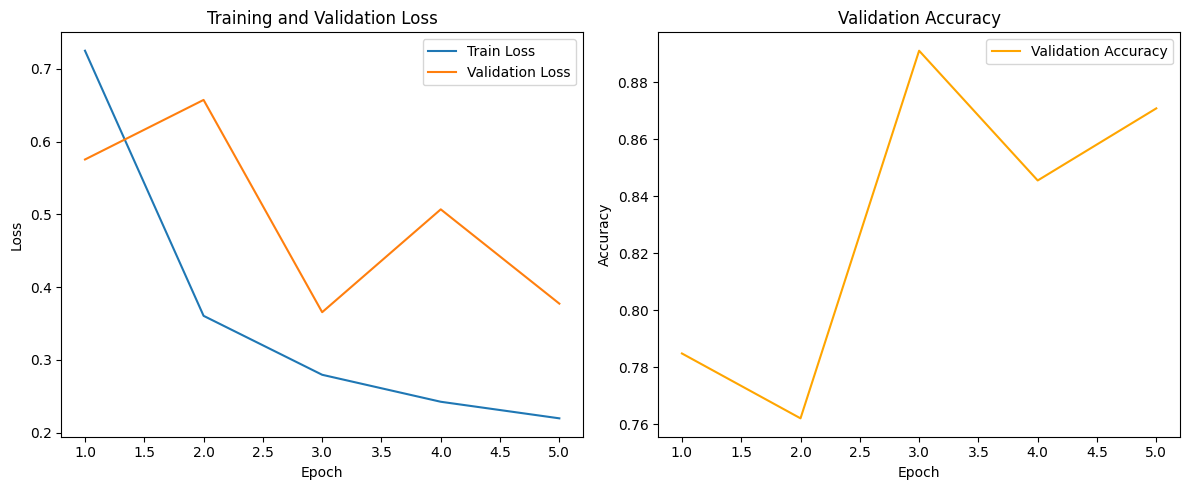

In [7]:
# Install timm for easy access to pre-trained models
!pip install timm --quiet

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import timm
import os
import matplotlib.pyplot as plt

# --- Configuration --- #
# Use the 'path' variable defined previously as the data root
data_dir = path

# Get class names from subfolders (assuming direct subfolders are classes)
class_names = sorted([d.name for d in os.scandir(data_dir) if d.is_dir()])
num_classes = len(class_names)

if num_classes == 0:
    print(f"Error: No class folders found in '{data_dir}'. Please ensure your data is structured with subfolders for each class.")
else:
    print(f"Found {num_classes} classes: {class_names}")

image_size = 224 # Standard input size for ResNet models
batch_size = 32
num_epochs = 5 # Reduced for a quicker run. Increase for better training.
learning_rate = 0.001
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# --- Data Transformations --- #
# Data augmentation and normalization for training
train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(image_size),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Just normalization for validation/testing
val_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(image_size),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# --- Dataset and DataLoader --- #
# This assumes your data is split into 'train' and 'val' subdirectories within your data_dir
# For simplicity, we'll use the whole dataset as training data for this run if no explicit splits exist.
# In a real scenario, you'd split your dataset into training, validation, and test sets.

# Check if train/val splits exist, otherwise use the whole dataset as 'train'
if os.path.exists(os.path.join(data_dir, 'train')) and os.path.exists(os.path.join(data_dir, 'val')):
    train_dataset = datasets.ImageFolder(os.path.join(data_dir, 'train'), train_transforms)
    val_dataset = datasets.ImageFolder(os.path.join(data_dir, 'val'), val_transforms)
    print("Using 'train' and 'val' subfolders for data loading.")
elif os.path.exists(data_dir):
    # If no explicit train/val, we'll split the main data_dir
    full_dataset = datasets.ImageFolder(data_dir, train_transforms) # Using train_transforms for full dataset
    train_size = int(0.8 * len(full_dataset))
    val_size = len(full_dataset) - train_size
    train_dataset, val_dataset = torch.utils.data.random_split(full_dataset, [train_size, val_size])
    # Note: For evaluation, the val_dataset should ideally use val_transforms. This simple split uses train_transforms.
    # For a more robust solution, create two ImageFolder instances with different transforms before splitting.
    print(f"No 'train'/'val' subfolders found. Splitting full dataset into {train_size} training and {val_size} validation samples.")
else:
    print(f"Error: Data directory '{data_dir}' not found.")
    exit()


train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

# --- Model Setup (ResNet50) --- #
# Load a pre-trained ResNet50 model
model = timm.create_model('resnet50', pretrained=True)

# Modify the final fully connected layer for our number of classes
# The number of input features to the fc layer depends on the model architecture
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, num_classes)

model = model.to(device)

# --- Loss and Optimizer --- #
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# --- Training Loop --- #
print("\nStarting training...")

train_losses = []
val_losses = []
val_accuracies = []

for epoch in range(num_epochs):
    model.train() # Set model to training mode
    running_loss = 0.0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)

    epoch_loss = running_loss / len(train_dataset)
    train_losses.append(epoch_loss)

    # Validation phase
    model.eval() # Set model to evaluation mode
    val_running_loss = 0.0
    correct_predictions = 0
    total_predictions = 0
    with torch.no_grad(): # Disable gradient calculation for validation
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_running_loss += loss.item() * inputs.size(0)

            _, predicted = torch.max(outputs.data, 1)
            total_predictions += labels.size(0)
            correct_predictions += (predicted == labels).sum().item()

    val_epoch_loss = val_running_loss / len(val_dataset)
    val_epoch_accuracy = correct_predictions / total_predictions
    val_losses.append(val_epoch_loss)
    val_accuracies.append(val_epoch_accuracy)

    print(f"Epoch {epoch+1}/{num_epochs} - Train Loss: {epoch_loss:.4f}, Val Loss: {val_epoch_loss:.4f}, Val Accuracy: {val_epoch_accuracy:.4f}")

print("\nTraining complete!")

# --- Plotting Results --- #
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(range(1, num_epochs + 1), train_losses, label='Train Loss')
plt.plot(range(1, num_epochs + 1), val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(1, num_epochs + 1), val_accuracies, label='Validation Accuracy', color='orange')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Validation Accuracy')
plt.legend()

plt.tight_layout()
plt.show()


Generating predictions for classification report and confusion matrix...

--- Classification Report ---
              precision    recall  f1-score   support

         FMD       0.96      0.43      0.59        56
 HEALTHY FMD       0.93      0.80      0.86        92
 HEALTHY LSD       0.93      0.96      0.94       149
         LSD       0.71      0.98      0.82        98

    accuracy                           0.85       395
   macro avg       0.88      0.79      0.80       395
weighted avg       0.88      0.85      0.84       395


--- Confusion Matrix ---


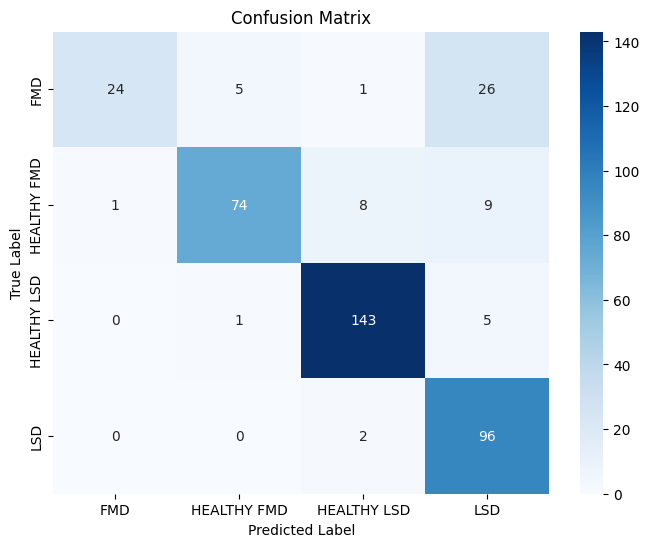

Analysis complete.


In [8]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure the model is in evaluation mode
model.eval()

# Store all predictions and true labels
all_preds = []
all_labels = []

print("\nGenerating predictions for classification report and confusion matrix...")
with torch.no_grad():
    for inputs, labels in val_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Convert to numpy arrays
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# --- Classification Report ---
print("\n--- Classification Report ---")
print(classification_report(all_labels, all_preds, target_names=class_names))

# --- Confusion Matrix ---
print("\n--- Confusion Matrix ---")
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

print("Analysis complete.")